# GRU Classification: From Scratch vs Library (Window Size = 14)

- Dataset: `CLASSIFY-SnP_daily_update_AMZN_features_with_target.csv`
- Target: `Target_Return_7d` mapped to 3 classes
  - Uptrend: `> 0.03`
  - Downtrend: `< -0.03`
  - Sideway: otherwise
- Features: selected from `CLASSIFY-AMZN_methods_all_in_one.csv`
- Models:
  1. GRU (from scratch — NumPy, forward/backward pass with **Adam optimizer**)
  2. GRU (PyTorch `nn.GRU` with **dropout, LR scheduler, early stopping, class weighting**)

Improvements over baseline:
- **Train/Val/Test split** (80/10/10) for proper early stopping
- **Class-weighted loss** to handle imbalanced classes
- **From-scratch**: Adam optimizer, mini-batch training, LR decay
- **Library**: 2-layer GRU, dropout, ReduceLROnPlateau, early stopping

Outputs:
- Loss
- Confusion matrix
- Accuracy
- Precision, Recall, Specificity (macro), F1-score
- ROC & AUC (multiclass, OvR)
- Performance curves (loss and accuracy)

Rows after cleaning: 4022
Number of features used: 9
Features used: ['ma_gap_20', 'vol_10', 'vol_20', 'lower_wick', 'upper_wick', 'ret_1', 'range_pct', 'co_ret', 'ret_5']

Target mapping:
  > 0.03 -> Uptrend (2)
  < -0.03 -> Downtrend (0)
  otherwise -> Sideway (1)
Class distribution: {'Downtrend': 784, 'Sideway': 2035, 'Uptrend': 1203}

X_train shape: (3206, 14, 9)  (samples, timesteps, features)
X_val   shape: (401, 14, 9)
X_test  shape: (401, 14, 9)
Class weights: {'Downtrend': np.float64(1.71), 'Sideway': np.float64(0.656), 'Uptrend': np.float64(1.123)}

Subsampled training set for scratch GRU: 3206 -> 1500

Training GRU from scratch (hidden=48, epochs=120, Adam + mini-batch) ...
  Epoch 1/120 — loss: 1.1323, acc: 0.3773 | val_loss: 1.1102, val_acc: 0.3965 (lr=0.002000)
  Epoch 10/120 — loss: 0.9321, acc: 0.5220 | val_loss: 1.1894, val_acc: 0.3541 (lr=0.001912)
  Epoch 20/120 — loss: 0.6142, acc: 0.6847 | val_loss: 1.4302, val_acc: 0.3691 (lr=0.001818)
  Early stopping at epoch 23 

c:\Users\ssupa\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Training PyTorch GRU (hidden=64, epochs=150, 2-layer, dropout=0.3, class-weighted) ...
  Epoch 1/150 — loss: 1.0910, acc: 0.3812 | val_loss: 1.0867, val_acc: 0.4090 (lr=0.001000)
  Epoch 10/150 — loss: 1.0230, acc: 0.4314 | val_loss: 1.2102, val_acc: 0.2793 (lr=0.001000)
  Epoch 20/150 — loss: 0.8805, acc: 0.5256 | val_loss: 1.4874, val_acc: 0.3491 (lr=0.000500)
  Early stopping at epoch 23 (no val improvement for 20 epochs)
  Restored best model (val_loss=1.0831)
=== Loss ===
Scratch log loss: 1.101671
Library log loss: 1.079840

=== Confusion Matrix (rows=true, cols=pred) ===
Class order: ['Downtrend', 'Sideway', 'Uptrend']
Scratch:
 [[ 17  42  35]
 [ 30 100  55]
 [ 31  45  46]]
Library:
 [[  8  62  24]
 [ 26 121  38]
 [ 28  60  34]]

=== Per-Class Metrics (Scratch) ===
Downtrend  | Precision: 0.2179 | Recall: 0.1809 | F1: 0.1977 | Support: 94
Sideway    | Precision: 0.5348 | Recall: 0.5405 | F1: 0.5376 | Support: 185
Uptrend    | Precision: 0.3382 | Recall: 0.3770 | F1: 0.3566 | Sup

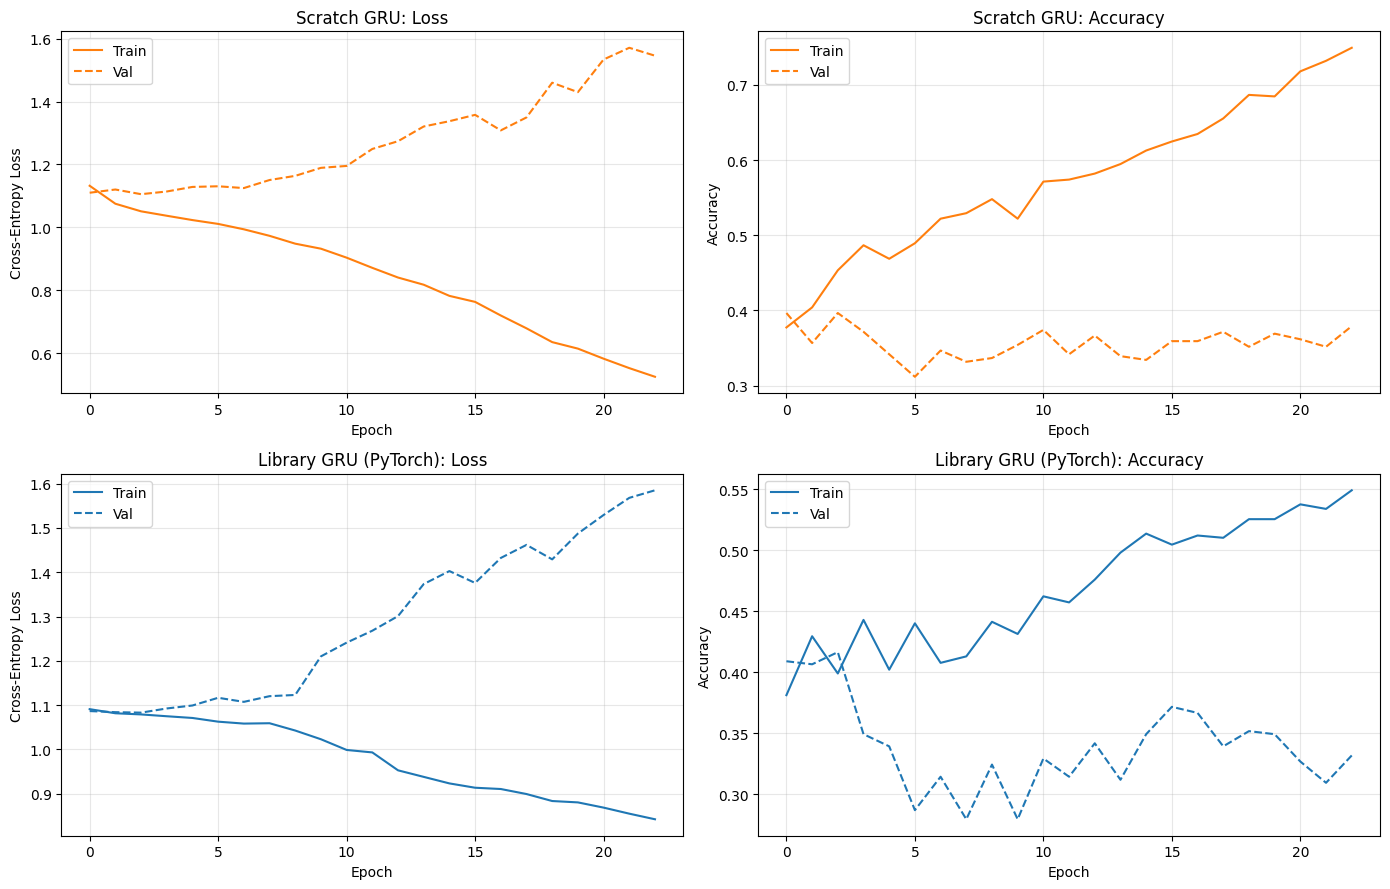

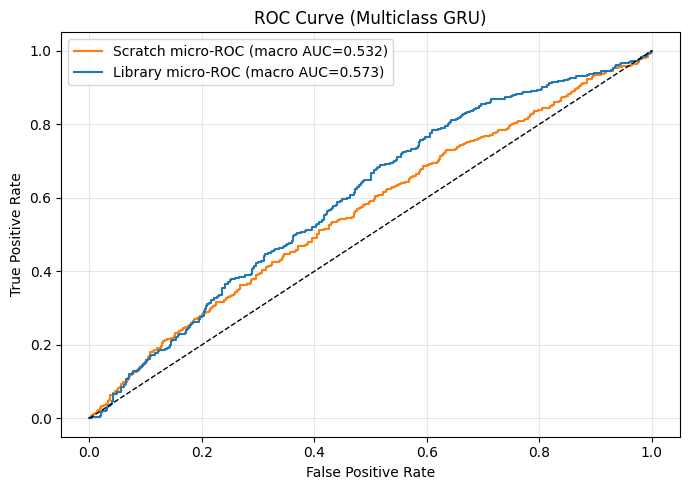

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import copy

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from sklearn.metrics import (
    log_loss,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    precision_recall_fscore_support,
    mean_squared_error,
    r2_score,
    roc_curve,
    roc_auc_score
)
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight

WINDOW_SIZE = 14
DATA_PATH = '../CLASSIFY-SnP_daily_update_AMZN_features_with_target.csv'
FEATURE_PATH = '../CLASSIFY-AMZN_methods_all_in_one.csv'
TARGET_COL = 'Target_Return_7d'

UP_THRESHOLD = 0.03
DOWN_THRESHOLD = -0.03

# --------------------------
# 1) Load data and features
# --------------------------
df = pd.read_csv(DATA_PATH)
feature_df = pd.read_csv(FEATURE_PATH)

requested_features = [
    'ma_gap_20', 'vol_10', 'vol_20',
    'lower_wick', 'upper_wick',
    'ret_1',
    'range_pct',
    'co_ret',
    'ret_5'
]
allowed_features = feature_df['feature'].tolist() if 'feature' in feature_df.columns else []
feature_cols = [c for c in requested_features if c in allowed_features and c in df.columns and c != TARGET_COL]
missing = [c for c in requested_features if c not in feature_cols]
if missing:
    print('Missing features:', missing)

if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
    df = df.sort_values('Date').reset_index(drop=True)

model_df = df[feature_cols + [TARGET_COL]].copy()
model_df = model_df.replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)

print(f'Rows after cleaning: {len(model_df)}')
print(f'Number of features used: {len(feature_cols)}')
print('Features used:', feature_cols)

# --------------------------------
# 2) Build sliding window features (keep 3D for GRU: samples x timesteps x features)
# --------------------------------
def map_target_3class(y_values, up_thr=0.03, down_thr=-0.03):
    y_cls = np.full_like(y_values, 1, dtype=np.int64)
    y_cls[y_values > up_thr] = 2
    y_cls[y_values < down_thr] = 0
    return y_cls

CLASS_LABELS = {0: 'Downtrend', 1: 'Sideway', 2: 'Uptrend'}
N_CLASSES = 3

X_raw = model_df[feature_cols].values.astype(np.float64)
y_raw_cont = model_df[TARGET_COL].values.astype(np.float64)
y_raw = map_target_3class(y_raw_cont, up_thr=UP_THRESHOLD, down_thr=DOWN_THRESHOLD)

print('\nTarget mapping:')
print(f'  > {UP_THRESHOLD:.2f} -> Uptrend (2)')
print(f'  < {DOWN_THRESHOLD:.2f} -> Downtrend (0)')
print('  otherwise -> Sideway (1)')
print('Class distribution:', {CLASS_LABELS[k]: int((y_raw == k).sum()) for k in sorted(CLASS_LABELS)})

# 3D windows: (samples, WINDOW_SIZE, n_features)
def make_windows_3d(x_values, y_values, window_size=14):
    Xw, yw = [], []
    for i in range(window_size, len(x_values)):
        Xw.append(x_values[i - window_size:i])
        yw.append(y_values[i])
    return np.array(Xw, dtype=np.float64), np.array(yw, dtype=np.int64)

X_win, y_win = make_windows_3d(X_raw, y_raw, window_size=WINDOW_SIZE)
n_features = X_win.shape[2]

# *** IMPROVEMENT: Chronological split 80/10/10 (train/val/test) ***
split_train = int(len(X_win) * 0.8)
split_val = int(len(X_win) * 0.9)
X_train_raw, X_val_raw, X_test_raw = X_win[:split_train], X_win[split_train:split_val], X_win[split_val:]
y_train, y_val, y_test = y_win[:split_train], y_win[split_train:split_val], y_win[split_val:]

# Standardize per feature across all timesteps (using train stats)
x_mean = X_train_raw.reshape(-1, n_features).mean(axis=0)
x_std = X_train_raw.reshape(-1, n_features).std(axis=0)
x_std = np.where(x_std == 0, 1.0, x_std)

X_train = (X_train_raw - x_mean) / x_std
X_val = (X_val_raw - x_mean) / x_std
X_test = (X_test_raw - x_mean) / x_std

print(f'\nX_train shape: {X_train.shape}  (samples, timesteps, features)')
print(f'X_val   shape: {X_val.shape}')
print(f'X_test  shape: {X_test.shape}')

# *** IMPROVEMENT: Compute class weights for imbalanced data ***
class_weights = compute_class_weight('balanced', classes=np.array([0, 1, 2]), y=y_train)
print(f'Class weights: {dict(zip([CLASS_LABELS[i] for i in range(3)], np.round(class_weights, 3)))}')

# --------------------------------------------------
# 3) GRU from Scratch (NumPy) — with Adam optimizer & mini-batch
# --------------------------------------------------
class GRUScratchClassifier:
    """Multiclass GRU classifier from scratch using NumPy.
    Architecture: GRU cell -> Dense (hidden -> n_classes) -> Softmax

    Improvements:
    - Adam optimizer (momentum + adaptive learning rates)
    - Mini-batch training
    - Learning rate decay
    - Class-weighted cross-entropy loss
    - Validation-based early stopping
    """
    def __init__(self, input_size, hidden_size, n_classes, lr=0.001, epochs=100,
                 batch_size=64, seed=42, patience=15, lr_decay=0.98):
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.n_classes = n_classes
        self.lr = lr
        self.initial_lr = lr
        self.epochs = epochs
        self.batch_size = batch_size
        self.patience = patience
        self.lr_decay = lr_decay
        self.loss_history = []
        self.acc_history = []
        self.val_loss_history = []
        self.val_acc_history = []

        rng = np.random.RandomState(seed)
        scale_ih = np.sqrt(2.0 / (input_size + hidden_size))
        scale_hh = np.sqrt(2.0 / (hidden_size + hidden_size))

        # GRU gates: z (update), r (reset), n (new/candidate)
        self.W_z = rng.randn(input_size, hidden_size).astype(np.float64) * scale_ih
        self.W_r = rng.randn(input_size, hidden_size).astype(np.float64) * scale_ih
        self.W_n = rng.randn(input_size, hidden_size).astype(np.float64) * scale_ih
        self.U_z = rng.randn(hidden_size, hidden_size).astype(np.float64) * scale_hh
        self.U_r = rng.randn(hidden_size, hidden_size).astype(np.float64) * scale_hh
        self.U_n = rng.randn(hidden_size, hidden_size).astype(np.float64) * scale_hh
        self.b_z = np.zeros(hidden_size, dtype=np.float64)
        self.b_r = np.zeros(hidden_size, dtype=np.float64)
        self.b_n = np.zeros(hidden_size, dtype=np.float64)

        # Output layer
        scale_out = np.sqrt(2.0 / (hidden_size + n_classes))
        self.W_out = rng.randn(hidden_size, n_classes).astype(np.float64) * scale_out
        self.b_out = np.zeros(n_classes, dtype=np.float64)

        # *** IMPROVEMENT: Adam optimizer state ***
        self._param_names = [
            'W_z', 'W_r', 'W_n', 'U_z', 'U_r', 'U_n',
            'b_z', 'b_r', 'b_n', 'W_out', 'b_out'
        ]
        self._grad_names = [
            'dW_z', 'dW_r', 'dW_n', 'dU_z', 'dU_r', 'dU_n',
            'db_z', 'db_r', 'db_n', 'dW_out', 'db_out'
        ]
        self._adam_m = {name: np.zeros_like(getattr(self, name)) for name in self._param_names}
        self._adam_v = {name: np.zeros_like(getattr(self, name)) for name in self._param_names}
        self._adam_t = 0
        self._beta1 = 0.9
        self._beta2 = 0.999
        self._adam_eps = 1e-8

    def _sigmoid(self, x):
        x = np.clip(x, -500, 500)
        return 1.0 / (1.0 + np.exp(-x))

    def _tanh(self, x):
        return np.tanh(x)

    def _softmax(self, x):
        x_stable = x - np.max(x, axis=-1, keepdims=True)
        e = np.exp(x_stable)
        return e / np.sum(e, axis=-1, keepdims=True)

    def _forward_single(self, X_seq):
        """Forward pass for a single sequence. X_seq shape: (T, input_size)."""
        T = X_seq.shape[0]
        H = self.hidden_size
        h = np.zeros(H, dtype=np.float64)
        cache = {'x': [], 'h_prev': [], 'z': [], 'r': [], 'n_hat': [], 'h': []}

        for t in range(T):
            x_t = X_seq[t]
            h_prev = h.copy()
            z_t = self._sigmoid(x_t @ self.W_z + h_prev @ self.U_z + self.b_z)
            r_t = self._sigmoid(x_t @ self.W_r + h_prev @ self.U_r + self.b_r)
            n_t = self._tanh(x_t @ self.W_n + (r_t * h_prev) @ self.U_n + self.b_n)
            h = (1 - z_t) * n_t + z_t * h_prev

            cache['x'].append(x_t)
            cache['h_prev'].append(h_prev)
            cache['z'].append(z_t)
            cache['r'].append(r_t)
            cache['n_hat'].append(n_t)
            cache['h'].append(h.copy())

        logits = h @ self.W_out + self.b_out
        probs = self._softmax(logits)
        return probs, h, cache

    def _backward_single(self, cache, h_final, probs, y_onehot, sample_weight=1.0):
        """Backward pass for a single sequence. Returns gradients."""
        T = len(cache['x'])
        H = self.hidden_size

        d_logits = (probs - y_onehot) * sample_weight
        dW_out = np.outer(h_final, d_logits)
        db_out = d_logits.copy()
        dh = d_logits @ self.W_out.T

        dW_z = np.zeros_like(self.W_z); dW_r = np.zeros_like(self.W_r); dW_n = np.zeros_like(self.W_n)
        dU_z = np.zeros_like(self.U_z); dU_r = np.zeros_like(self.U_r); dU_n = np.zeros_like(self.U_n)
        db_z = np.zeros_like(self.b_z); db_r = np.zeros_like(self.b_r); db_n = np.zeros_like(self.b_n)

        for t in reversed(range(T)):
            x_t = cache['x'][t]
            h_prev = cache['h_prev'][t]
            z_t = cache['z'][t]
            r_t = cache['r'][t]
            n_t = cache['n_hat'][t]

            dh_prev_from_h = dh * z_t
            dz = dh * (h_prev - n_t)
            dn = dh * (1 - z_t)
            dn_raw = dn * (1 - n_t ** 2)
            d_rh = dn_raw @ self.U_n.T
            dr = d_rh * h_prev
            dr_raw = dr * r_t * (1 - r_t)
            dz_raw = dz * z_t * (1 - z_t)

            dW_n += np.outer(x_t, dn_raw)
            dU_n += np.outer(r_t * h_prev, dn_raw)
            db_n += dn_raw
            dW_z += np.outer(x_t, dz_raw)
            dU_z += np.outer(h_prev, dz_raw)
            db_z += dz_raw
            dW_r += np.outer(x_t, dr_raw)
            dU_r += np.outer(h_prev, dr_raw)
            db_r += dr_raw

            dh = dh_prev_from_h + d_rh * r_t + dz_raw @ self.U_z.T + dr_raw @ self.U_r.T

        grads = {
            'dW_z': dW_z, 'dW_r': dW_r, 'dW_n': dW_n,
            'dU_z': dU_z, 'dU_r': dU_r, 'dU_n': dU_n,
            'db_z': db_z, 'db_r': db_r, 'db_n': db_n,
            'dW_out': dW_out, 'db_out': db_out
        }
        return grads

    def _adam_update(self, grads):
        """*** IMPROVEMENT: Adam optimizer update ***"""
        self._adam_t += 1
        for pname, gname in zip(self._param_names, self._grad_names):
            g = grads[gname]
            # Gradient clipping
            gnorm = np.linalg.norm(g)
            if gnorm > 5.0:
                g = g * (5.0 / gnorm)

            self._adam_m[pname] = self._beta1 * self._adam_m[pname] + (1 - self._beta1) * g
            self._adam_v[pname] = self._beta2 * self._adam_v[pname] + (1 - self._beta2) * (g ** 2)
            m_hat = self._adam_m[pname] / (1 - self._beta1 ** self._adam_t)
            v_hat = self._adam_v[pname] / (1 - self._beta2 ** self._adam_t)
            setattr(self, pname, getattr(self, pname) - self.lr * m_hat / (np.sqrt(v_hat) + self._adam_eps))

    def fit(self, X, y, X_val=None, y_val=None, class_weights=None):
        """Train on X: (N, T, D), y: (N,) integer labels.
        *** IMPROVEMENT: mini-batch, Adam, LR decay, early stopping, class weights ***
        """
        N = X.shape[0]
        eps = 1e-9

        # Build sample weights from class weights
        if class_weights is not None:
            sample_w = np.array([class_weights[yi] for yi in y])
        else:
            sample_w = np.ones(N)

        best_val_loss = np.inf
        patience_counter = 0
        best_params = None

        for epoch in range(self.epochs):
            # *** IMPROVEMENT: LR decay ***
            self.lr = self.initial_lr * (self.lr_decay ** epoch)

            # *** IMPROVEMENT: Mini-batch with shuffling ***
            indices = np.random.permutation(N)
            total_loss = 0.0
            correct = 0

            for start in range(0, N, self.batch_size):
                batch_idx = indices[start:start + self.batch_size]
                grad_accum = None
                batch_loss = 0.0
                batch_correct = 0

                for i in batch_idx:
                    y_oh = np.zeros(self.n_classes, dtype=np.float64)
                    y_oh[y[i]] = 1.0
                    probs, h_final, cache = self._forward_single(X[i])
                    loss_i = -np.sum(y_oh * np.log(probs + eps)) * sample_w[i]
                    batch_loss += loss_i
                    batch_correct += (np.argmax(probs) == y[i])
                    grads = self._backward_single(cache, h_final, probs, y_oh, sample_weight=sample_w[i])

                    if grad_accum is None:
                        grad_accum = {k: v.copy() for k, v in grads.items()}
                    else:
                        for k in grad_accum:
                            grad_accum[k] += grads[k]

                bs = len(batch_idx)
                for k in grad_accum:
                    grad_accum[k] /= bs

                # *** IMPROVEMENT: Adam update instead of plain SGD ***
                self._adam_update(grad_accum)

                total_loss += batch_loss
                correct += batch_correct

            avg_loss = total_loss / N
            acc = correct / N
            self.loss_history.append(avg_loss)
            self.acc_history.append(acc)

            # *** IMPROVEMENT: Validation monitoring ***
            if X_val is not None:
                val_probs = self.predict_proba(X_val)
                val_loss = 0.0
                val_correct = 0
                for i in range(len(X_val)):
                    y_oh_v = np.zeros(self.n_classes, dtype=np.float64)
                    y_oh_v[y_val[i]] = 1.0
                    val_loss += -np.sum(y_oh_v * np.log(val_probs[i] + eps))
                    val_correct += (np.argmax(val_probs[i]) == y_val[i])
                val_loss /= len(X_val)
                val_acc = val_correct / len(X_val)
                self.val_loss_history.append(val_loss)
                self.val_acc_history.append(val_acc)

                # *** IMPROVEMENT: Early stopping ***
                if val_loss < best_val_loss:
                    best_val_loss = val_loss
                    patience_counter = 0
                    best_params = {name: getattr(self, name).copy() for name in self._param_names}
                else:
                    patience_counter += 1

                if (epoch + 1) % 10 == 0 or epoch == 0:
                    print(f'  Epoch {epoch+1}/{self.epochs} — loss: {avg_loss:.4f}, acc: {acc:.4f} | val_loss: {val_loss:.4f}, val_acc: {val_acc:.4f} (lr={self.lr:.6f})')

                if patience_counter >= self.patience:
                    print(f'  Early stopping at epoch {epoch+1} (no val improvement for {self.patience} epochs)')
                    break
            else:
                if (epoch + 1) % 10 == 0 or epoch == 0:
                    print(f'  Epoch {epoch+1}/{self.epochs} — loss: {avg_loss:.4f}, acc: {acc:.4f} (lr={self.lr:.6f})')

        # Restore best parameters
        if best_params is not None:
            for name in self._param_names:
                setattr(self, name, best_params[name])
            print(f'  Restored best model (val_loss={best_val_loss:.4f})')

    def predict_proba(self, X):
        N = X.shape[0]
        all_probs = np.zeros((N, self.n_classes), dtype=np.float64)
        for i in range(N):
            probs, _, _ = self._forward_single(X[i])
            all_probs[i] = probs
        return all_probs

    def predict(self, X):
        probs = self.predict_proba(X)
        return np.argmax(probs, axis=1)


# Subsample training data for scratch model (full BPTT is slow)
MAX_SCRATCH_TRAIN = 1500
rng_sub = np.random.RandomState(42)
if len(X_train) > MAX_SCRATCH_TRAIN:
    sub_idx = rng_sub.choice(len(X_train), MAX_SCRATCH_TRAIN, replace=False)
    sub_idx.sort()
    X_train_scratch = X_train[sub_idx]
    y_train_scratch = y_train[sub_idx]
    print(f'\nSubsampled training set for scratch GRU: {len(X_train)} -> {MAX_SCRATCH_TRAIN}')
else:
    X_train_scratch = X_train
    y_train_scratch = y_train

HIDDEN_SIZE = 48   # *** IMPROVEMENT: larger hidden size (was 32) ***
EPOCHS_SCRATCH = 120  # *** IMPROVEMENT: more epochs with early stopping (was 80) ***

print(f'\nTraining GRU from scratch (hidden={HIDDEN_SIZE}, epochs={EPOCHS_SCRATCH}, Adam + mini-batch) ...')
scratch_model = GRUScratchClassifier(
    input_size=n_features, hidden_size=HIDDEN_SIZE, n_classes=N_CLASSES,
    lr=0.002, epochs=EPOCHS_SCRATCH, batch_size=64, seed=42,
    patience=20, lr_decay=0.995
)
scratch_model.fit(X_train_scratch, y_train_scratch,
                  X_val=X_val, y_val=y_val,
                  class_weights=class_weights)
y_prob_scratch = scratch_model.predict_proba(X_test)
y_pred_scratch = scratch_model.predict(X_test)

# -------------------------------------
# 4) GRU Library (PyTorch) — with dropout, scheduler, early stopping, class weights
# -------------------------------------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'\nPyTorch device: {device}')

class GRUClassifierTorch(nn.Module):
    def __init__(self, input_size, hidden_size, n_classes, num_layers=2, dropout=0.3):
        super().__init__()
        # *** IMPROVEMENT: multi-layer GRU with dropout ***
        self.gru = nn.GRU(input_size, hidden_size, num_layers=num_layers,
                          batch_first=True, dropout=dropout if num_layers > 1 else 0.0)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, n_classes)

    def forward(self, x):
        out, _ = self.gru(x)
        out = out[:, -1, :]
        out = self.dropout(out)  # *** IMPROVEMENT: dropout before FC ***
        return self.fc(out)

HIDDEN_LIB = 64
EPOCHS_LIB = 150   # *** IMPROVEMENT: more epochs, early stopping will cut short ***
BATCH_SIZE = 64
LR_LIB = 0.001
PATIENCE_LIB = 20

X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train, dtype=torch.long).to(device)
X_val_t = torch.tensor(X_val, dtype=torch.float32).to(device)
y_val_t = torch.tensor(y_val, dtype=torch.long).to(device)
X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)

train_ds = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)

# *** IMPROVEMENT: 2-layer GRU with dropout ***
lib_model = GRUClassifierTorch(n_features, HIDDEN_LIB, N_CLASSES, num_layers=2, dropout=0.3).to(device)

# *** IMPROVEMENT: Class-weighted cross-entropy loss ***
cw_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)
criterion = nn.CrossEntropyLoss(weight=cw_tensor)

optimizer = optim.Adam(lib_model.parameters(), lr=LR_LIB, weight_decay=1e-5)  # *** IMPROVEMENT: weight decay ***
# *** IMPROVEMENT: Learning rate scheduler ***
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=8, verbose=False)

lib_loss_history = []
lib_acc_history = []
lib_val_loss_history = []
lib_val_acc_history = []

best_val_loss_lib = float('inf')
patience_counter_lib = 0
best_model_state = None

print(f'Training PyTorch GRU (hidden={HIDDEN_LIB}, epochs={EPOCHS_LIB}, 2-layer, dropout=0.3, class-weighted) ...')
for epoch in range(EPOCHS_LIB):
    lib_model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        logits = lib_model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(lib_model.parameters(), 5.0)
        optimizer.step()
        running_loss += loss.item() * xb.size(0)
        correct += (logits.argmax(dim=1) == yb).sum().item()
        total += xb.size(0)

    avg_loss = running_loss / total
    acc = correct / total
    lib_loss_history.append(avg_loss)
    lib_acc_history.append(acc)

    # *** IMPROVEMENT: Validation monitoring ***
    lib_model.eval()
    with torch.no_grad():
        val_logits = lib_model(X_val_t)
        val_loss = nn.CrossEntropyLoss(weight=cw_tensor)(val_logits, y_val_t).item()
        val_acc = (val_logits.argmax(dim=1) == y_val_t).float().mean().item()
    lib_val_loss_history.append(val_loss)
    lib_val_acc_history.append(val_acc)

    # *** IMPROVEMENT: LR scheduler step on val loss ***
    scheduler.step(val_loss)

    # *** IMPROVEMENT: Early stopping ***
    if val_loss < best_val_loss_lib:
        best_val_loss_lib = val_loss
        patience_counter_lib = 0
        best_model_state = copy.deepcopy(lib_model.state_dict())
    else:
        patience_counter_lib += 1

    if (epoch + 1) % 10 == 0 or epoch == 0:
        current_lr = optimizer.param_groups[0]['lr']
        print(f'  Epoch {epoch+1}/{EPOCHS_LIB} — loss: {avg_loss:.4f}, acc: {acc:.4f} | val_loss: {val_loss:.4f}, val_acc: {val_acc:.4f} (lr={current_lr:.6f})')

    if patience_counter_lib >= PATIENCE_LIB:
        print(f'  Early stopping at epoch {epoch+1} (no val improvement for {PATIENCE_LIB} epochs)')
        break

# Restore best model
if best_model_state is not None:
    lib_model.load_state_dict(best_model_state)
    print(f'  Restored best model (val_loss={best_val_loss_lib:.4f})')

lib_model.eval()
with torch.no_grad():
    logits_test = lib_model(X_test_t)
    y_prob_lib = torch.softmax(logits_test, dim=1).cpu().numpy()
    y_pred_lib = logits_test.argmax(dim=1).cpu().numpy()

# ------------------------
# 5) Metrics and outputs
# ------------------------
classes = np.array([0, 1, 2])

loss_scratch = log_loss(y_test, y_prob_scratch, labels=classes)
loss_lib = log_loss(y_test, y_prob_lib, labels=classes)

cm_scratch = confusion_matrix(y_test, y_pred_scratch, labels=classes)
cm_lib = confusion_matrix(y_test, y_pred_lib, labels=classes)

acc_scratch = accuracy_score(y_test, y_pred_scratch)
acc_lib = accuracy_score(y_test, y_pred_lib)

precision_scratch = precision_score(y_test, y_pred_scratch, average='macro', zero_division=0)
precision_lib = precision_score(y_test, y_pred_lib, average='macro', zero_division=0)

recall_scratch = recall_score(y_test, y_pred_scratch, average='macro', zero_division=0)
recall_lib = recall_score(y_test, y_pred_lib, average='macro', zero_division=0)

f1_scratch = f1_score(y_test, y_pred_scratch, average='macro', zero_division=0)
f1_lib = f1_score(y_test, y_pred_lib, average='macro', zero_division=0)

mse_scratch = mean_squared_error(y_test, y_pred_scratch)
mse_lib = mean_squared_error(y_test, y_pred_lib)
rmse_scratch = np.sqrt(mse_scratch)
rmse_lib = np.sqrt(mse_lib)
r2_scratch = r2_score(y_test, y_pred_scratch)
r2_lib = r2_score(y_test, y_pred_lib)

def multiclass_macro_specificity(cm):
    total = np.sum(cm)
    specs = []
    for i in range(cm.shape[0]):
        tp = cm[i, i]
        fp = np.sum(cm[:, i]) - tp
        fn = np.sum(cm[i, :]) - tp
        tn = total - (tp + fp + fn)
        specs.append(tn / (tn + fp) if (tn + fp) > 0 else 0.0)
    return float(np.mean(specs))

specificity_scratch = multiclass_macro_specificity(cm_scratch)
specificity_lib = multiclass_macro_specificity(cm_lib)

print('=== Loss ===')
print(f'Scratch log loss: {loss_scratch:.6f}')
print(f'Library log loss: {loss_lib:.6f}')

print('\n=== Confusion Matrix (rows=true, cols=pred) ===')
print('Class order:', [CLASS_LABELS[c] for c in classes])
print('Scratch:\n', cm_scratch)
print('Library:\n', cm_lib)

p_s, r_s, f_s, sup_s = precision_recall_fscore_support(y_test, y_pred_scratch, labels=classes, zero_division=0)
p_l, r_l, f_l, sup_l = precision_recall_fscore_support(y_test, y_pred_lib, labels=classes, zero_division=0)

print('\n=== Per-Class Metrics (Scratch) ===')
for i, c in enumerate(classes):
    print(f"{CLASS_LABELS[c]:<10} | Precision: {p_s[i]:.4f} | Recall: {r_s[i]:.4f} | F1: {f_s[i]:.4f} | Support: {sup_s[i]}")

print('\n=== Per-Class Metrics (Library) ===')
for i, c in enumerate(classes):
    print(f"{CLASS_LABELS[c]:<10} | Precision: {p_l[i]:.4f} | Recall: {r_l[i]:.4f} | F1: {f_l[i]:.4f} | Support: {sup_l[i]}")

print('\n=== Metrics Summary (Macro) ===')
print(f'Accuracy - Scratch: {acc_scratch:.4f} | Library: {acc_lib:.4f}')
print(f'Precision - Scratch: {precision_scratch:.4f} | Library: {precision_lib:.4f}')
print(f'Recall - Scratch: {recall_scratch:.4f} | Library: {recall_lib:.4f}')
print(f'Specificity - Scratch: {specificity_scratch:.4f} | Library: {specificity_lib:.4f}')
print(f'F1-score - Scratch: {f1_scratch:.4f} | Library: {f1_lib:.4f}')

print('\n=== Additional Numeric Metrics (Label-Encoded) ===')
print(f'MSE - Scratch: {mse_scratch:.4f} | Library: {mse_lib:.4f}')
print(f'RMSE - Scratch: {rmse_scratch:.4f} | Library: {rmse_lib:.4f}')
print(f'R² - Scratch: {r2_scratch:.4f} | Library: {r2_lib:.4f}')

# ROC & AUC (multiclass OvR + micro-curve for plotting)
y_test_bin = label_binarize(y_test, classes=classes)

roc_auc_s = roc_auc_score(y_test_bin, y_prob_scratch, average='macro', multi_class='ovr')
roc_auc_l = roc_auc_score(y_test_bin, y_prob_lib, average='macro', multi_class='ovr')

fpr_s, tpr_s, _ = roc_curve(y_test_bin.ravel(), y_prob_scratch.ravel())
fpr_l, tpr_l, _ = roc_curve(y_test_bin.ravel(), y_prob_lib.ravel())

print('\n=== ROC & AUC (Multiclass OvR Macro AUC) ===')
print(f'Scratch AUC: {roc_auc_s:.4f}')
print(f'Library AUC: {roc_auc_l:.4f}')

# ---------------------------------------------------------
# 6) Performance curves (loss + accuracy) and ROC
# ---------------------------------------------------------
# Training + Validation loss/accuracy curves
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Scratch: Loss
axes[0, 0].plot(scratch_model.loss_history, label='Train', color='tab:orange')
if scratch_model.val_loss_history:
    axes[0, 0].plot(scratch_model.val_loss_history, label='Val', color='tab:orange', linestyle='--')
axes[0, 0].set_title('Scratch GRU: Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Cross-Entropy Loss')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Scratch: Accuracy
axes[0, 1].plot(scratch_model.acc_history, label='Train', color='tab:orange')
if scratch_model.val_acc_history:
    axes[0, 1].plot(scratch_model.val_acc_history, label='Val', color='tab:orange', linestyle='--')
axes[0, 1].set_title('Scratch GRU: Accuracy')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Library: Loss
axes[1, 0].plot(lib_loss_history, label='Train', color='tab:blue')
axes[1, 0].plot(lib_val_loss_history, label='Val', color='tab:blue', linestyle='--')
axes[1, 0].set_title('Library GRU (PyTorch): Loss')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Cross-Entropy Loss')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Library: Accuracy
axes[1, 1].plot(lib_acc_history, label='Train', color='tab:blue')
axes[1, 1].plot(lib_val_acc_history, label='Val', color='tab:blue', linestyle='--')
axes[1, 1].set_title('Library GRU (PyTorch): Accuracy')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Accuracy')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ROC Curve (micro-averaged one-vs-rest)
plt.figure(figsize=(7, 5))
plt.plot(fpr_s, tpr_s, label=f'Scratch micro-ROC (macro AUC={roc_auc_s:.3f})', color='tab:orange')
plt.plot(fpr_l, tpr_l, label=f'Library micro-ROC (macro AUC={roc_auc_l:.3f})', color='tab:blue')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
plt.title('ROC Curve (Multiclass GRU)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Grid Search Hyperparameter Tuning

Perform grid search over key hyperparameters for both models using **validation accuracy** as the selection criterion.

### Scratch GRU Search Space (reduced grid — BPTT is slow)
| Hyperparameter | Values |
|---|---|
| `hidden_size` | 32, 48, 64 |
| `learning_rate` | 0.001, 0.002, 0.005 |
| `lr_decay` | 0.99, 0.995 |

### PyTorch GRU Search Space
| Hyperparameter | Values |
|---|---|
| `hidden_size` | 32, 64, 128 |
| `num_layers` | 1, 2 |
| `dropout` | 0.2, 0.3, 0.5 |
| `learning_rate` | 0.0005, 0.001, 0.002 |

Best hyperparameters are selected by highest validation accuracy, then the final model is retrained and evaluated on the test set.

In [1]:
##############################################
# Grid Search — Scratch GRU
##############################################
from itertools import product
import time

scratch_param_grid = {
    'hidden_size': [32, 48, 64],
    'lr': [0.001, 0.002, 0.005, 0.01],
    'lr_decay': [0.99, 0.995, 0.998],
}

scratch_grid = list(product(
    scratch_param_grid['hidden_size'],
    scratch_param_grid['lr'],
    scratch_param_grid['lr_decay'],
))

print(f'Scratch GRU grid search: {len(scratch_grid)} combinations\n')

scratch_results = []
best_scratch_val_acc = -1
best_scratch_params = None
best_scratch_model_obj = None

for idx, (hs, lr, lrd) in enumerate(scratch_grid):
    t0 = time.time()
    model = GRUScratchClassifier(
        input_size=n_features, hidden_size=hs, n_classes=N_CLASSES,
        lr=lr, epochs=EPOCHS_SCRATCH, batch_size=64, seed=42,
        patience=20, lr_decay=lrd,
    )
    # Suppress per-epoch printing during grid search
    import io, sys
    old_stdout = sys.stdout
    sys.stdout = io.StringIO()
    model.fit(X_train_scratch, y_train_scratch, X_val=X_val, y_val=y_val, class_weights=class_weights)
    sys.stdout = old_stdout

    val_probs = model.predict_proba(X_val)
    val_preds = np.argmax(val_probs, axis=1)
    val_acc = accuracy_score(y_val, val_preds)
    val_f1 = f1_score(y_val, val_preds, average='macro', zero_division=0)
    elapsed = time.time() - t0

    scratch_results.append({
        'hidden_size': hs, 'lr': lr, 'lr_decay': lrd,
        'val_acc': val_acc, 'val_f1': val_f1, 'time_s': elapsed
    })

    if val_acc > best_scratch_val_acc:
        best_scratch_val_acc = val_acc
        best_scratch_params = {'hidden_size': hs, 'lr': lr, 'lr_decay': lrd}
        best_scratch_model_obj = model

    print(f'  [{idx+1}/{len(scratch_grid)}] hs={hs}, lr={lr}, lr_decay={lrd} '
          f'-> val_acc={val_acc:.4f}, val_f1={val_f1:.4f} ({elapsed:.1f}s)')

scratch_grid_df = pd.DataFrame(scratch_results).sort_values('val_acc', ascending=False).reset_index(drop=True)
print(f'\n=== Best Scratch GRU Params (val_acc={best_scratch_val_acc:.4f}) ===')
print(best_scratch_params)
print('\nFull grid results:')
print(scratch_grid_df.to_string(index=False))

Scratch GRU grid search: 36 combinations



NameError: name 'GRUScratchClassifier' is not defined

In [4]:
##############################################
# Grid Search — PyTorch GRU
##############################################

lib_param_grid = {
    'hidden_size': [32, 64, 128],
    'num_layers': [1, 2],
    'dropout': [0.2, 0.3, 0.5],
    'lr': [0.0005, 0.001, 0.002],
}

lib_grid = list(product(
    lib_param_grid['hidden_size'],
    lib_param_grid['num_layers'],
    lib_param_grid['dropout'],
    lib_param_grid['lr'],
))

print(f'PyTorch GRU grid search: {len(lib_grid)} combinations\n')

lib_results = []
best_lib_val_acc = -1
best_lib_params = None
best_lib_state_dict = None

for idx, (hs, nl, drp, lr) in enumerate(lib_grid):
    t0 = time.time()

    model = GRUClassifierTorch(n_features, hs, N_CLASSES, num_layers=nl, dropout=drp).to(device)
    cw_t = torch.tensor(class_weights, dtype=torch.float32).to(device)
    crit = nn.CrossEntropyLoss(weight=cw_t)
    opt = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    sched = optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', factor=0.5, patience=8, verbose=False)

    loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=BATCH_SIZE, shuffle=True)

    _best_vl = float('inf')
    _patience = 0
    _best_state = None

    for ep in range(EPOCHS_LIB):
        model.train()
        for xb, yb in loader:
            opt.zero_grad()
            out = model(xb)
            l = crit(out, yb)
            l.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            opt.step()

        model.eval()
        with torch.no_grad():
            vl = nn.CrossEntropyLoss(weight=cw_t)(model(X_val_t), y_val_t).item()
        sched.step(vl)

        if vl < _best_vl:
            _best_vl = vl
            _patience = 0
            _best_state = copy.deepcopy(model.state_dict())
        else:
            _patience += 1
        if _patience >= PATIENCE_LIB:
            break

    # Restore best epoch and evaluate
    if _best_state is not None:
        model.load_state_dict(_best_state)
    model.eval()
    with torch.no_grad():
        val_logits_gs = model(X_val_t)
        val_preds_gs = val_logits_gs.argmax(dim=1).cpu().numpy()
    val_acc = accuracy_score(y_val, val_preds_gs)
    val_f1 = f1_score(y_val, val_preds_gs, average='macro', zero_division=0)
    elapsed = time.time() - t0

    lib_results.append({
        'hidden_size': hs, 'num_layers': nl, 'dropout': drp, 'lr': lr,
        'val_acc': val_acc, 'val_f1': val_f1, 'time_s': elapsed
    })

    if val_acc > best_lib_val_acc:
        best_lib_val_acc = val_acc
        best_lib_params = {'hidden_size': hs, 'num_layers': nl, 'dropout': drp, 'lr': lr}
        best_lib_state_dict = copy.deepcopy(model.state_dict())

    print(f'  [{idx+1}/{len(lib_grid)}] hs={hs}, layers={nl}, drop={drp}, lr={lr} '
          f'-> val_acc={val_acc:.4f}, val_f1={val_f1:.4f} ({elapsed:.1f}s)')

lib_grid_df = pd.DataFrame(lib_results).sort_values('val_acc', ascending=False).reset_index(drop=True)
print(f'\n=== Best PyTorch GRU Params (val_acc={best_lib_val_acc:.4f}) ===')
print(best_lib_params)
print('\nTop 10 grid results:')
print(lib_grid_df.head(10).to_string(index=False))

PyTorch GRU grid search: 54 combinations



c:\Users\ssupa\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


  [1/54] hs=32, layers=1, drop=0.2, lr=0.0005 -> val_acc=0.4489, val_f1=0.3996 (3.1s)


c:\Users\ssupa\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


  [2/54] hs=32, layers=1, drop=0.2, lr=0.001 -> val_acc=0.4439, val_f1=0.4047 (2.9s)


...

  [52/54] hs=128, layers=2, drop=0.5, lr=0.0005 -> val_acc=0.4589, val_f1=0.3916 (3.1s)


c:\Users\ssupa\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


  [53/54] hs=128, layers=2, drop=0.5, lr=0.001 -> val_acc=0.3616, val_f1=0.2972 (3.4s)


c:\Users\ssupa\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


  [54/54] hs=128, layers=2, drop=0.5, lr=0.002 -> val_acc=0.4838, val_f1=0.4010 (3.1s)

=== Best PyTorch GRU Params (val_acc=0.4838) ===
{'hidden_size': 128, 'num_layers': 2, 'dropout': 0.5, 'lr': 0.002}

Top 10 grid results:
 hidden_size  num_layers  dropout     lr  val_acc   val_f1   time_s
         128           2      0.5 0.0020 0.483791 0.401032 3.072026
         128           1      0.5 0.0010 0.466334 0.414074 2.681683
          32           1      0.2 0.0020 0.463840 0.436654 2.952205
          64           1      0.2 0.0005 0.463840 0.406984 2.671245
          32           2      0.5 0.0020 0.458853 0.389369 3.074437
         128           2      0.5 0.0005 0.458853 0.391618 3.079976
          64           1      0.5 0.0005 0.456359 0.417669 2.894371
          32           1      0.5 0.0005 0.456359 0.414034 3.391216
          64           2      0.5 0.0010 0.456359 0.408501 3.054925
         128           1      0.3 0.0005 0.456359 0.410735 2.835320


  GRID SEARCH — BEST MODEL TEST SET EVALUATION

Best Scratch GRU params: {'hidden_size': 48, 'lr': 0.005, 'lr_decay': 0.99}
Best PyTorch GRU params: {'hidden_size': 128, 'num_layers': 2, 'dropout': 0.5, 'lr': 0.002}

=== Loss ===
Scratch log loss: 1.112058
Library log loss: 1.082993

=== Confusion Matrix (rows=true, cols=pred) ===
Class order: ['Downtrend', 'Sideway', 'Uptrend']
Scratch:
 [[ 14  45  35]
 [ 25 102  58]
 [ 24  45  53]]
Library:
 [[  3  61  30]
 [  6 123  56]
 [ 13  63  46]]

=== Per-Class Metrics (Scratch — Grid Search Best) ===
Downtrend  | Precision: 0.2222 | Recall: 0.1489 | F1: 0.1783 | Support: 94
Sideway    | Precision: 0.5312 | Recall: 0.5514 | F1: 0.5411 | Support: 185
Uptrend    | Precision: 0.3630 | Recall: 0.4344 | F1: 0.3955 | Support: 122

=== Per-Class Metrics (Library — Grid Search Best) ===
Downtrend  | Precision: 0.1364 | Recall: 0.0319 | F1: 0.0517 | Support: 94
Sideway    | Precision: 0.4980 | Recall: 0.6649 | F1: 0.5694 | Support: 185
Uptrend    | Pre

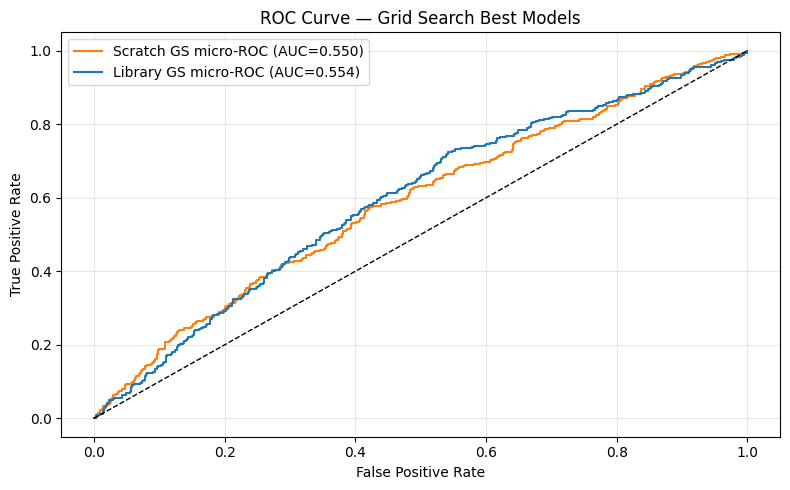

In [5]:
##############################################
# Evaluate Best Models from Grid Search on Test Set
##############################################

# --- Best Scratch GRU (already trained, stored in best_scratch_model_obj) ---
y_prob_scratch_gs = best_scratch_model_obj.predict_proba(X_test)
y_pred_scratch_gs = best_scratch_model_obj.predict(X_test)

# --- Best PyTorch GRU (load best state dict into a new model) ---
best_lib_model_gs = GRUClassifierTorch(
    n_features,
    best_lib_params['hidden_size'],
    N_CLASSES,
    num_layers=best_lib_params['num_layers'],
    dropout=best_lib_params['dropout'],
).to(device)
best_lib_model_gs.load_state_dict(best_lib_state_dict)
best_lib_model_gs.eval()

with torch.no_grad():
    logits_test_gs = best_lib_model_gs(X_test_t)
    y_prob_lib_gs = torch.softmax(logits_test_gs, dim=1).cpu().numpy()
    y_pred_lib_gs = logits_test_gs.argmax(dim=1).cpu().numpy()

# --- Metrics ---
loss_scratch_gs = log_loss(y_test, y_prob_scratch_gs, labels=classes)
loss_lib_gs = log_loss(y_test, y_prob_lib_gs, labels=classes)

cm_scratch_gs = confusion_matrix(y_test, y_pred_scratch_gs, labels=classes)
cm_lib_gs = confusion_matrix(y_test, y_pred_lib_gs, labels=classes)

acc_scratch_gs = accuracy_score(y_test, y_pred_scratch_gs)
acc_lib_gs = accuracy_score(y_test, y_pred_lib_gs)

precision_scratch_gs = precision_score(y_test, y_pred_scratch_gs, average='macro', zero_division=0)
precision_lib_gs = precision_score(y_test, y_pred_lib_gs, average='macro', zero_division=0)

recall_scratch_gs = recall_score(y_test, y_pred_scratch_gs, average='macro', zero_division=0)
recall_lib_gs = recall_score(y_test, y_pred_lib_gs, average='macro', zero_division=0)

f1_scratch_gs = f1_score(y_test, y_pred_scratch_gs, average='macro', zero_division=0)
f1_lib_gs = f1_score(y_test, y_pred_lib_gs, average='macro', zero_division=0)

specificity_scratch_gs = multiclass_macro_specificity(cm_scratch_gs)
specificity_lib_gs = multiclass_macro_specificity(cm_lib_gs)

mse_scratch_gs = mean_squared_error(y_test, y_pred_scratch_gs)
mse_lib_gs = mean_squared_error(y_test, y_pred_lib_gs)
rmse_scratch_gs = np.sqrt(mse_scratch_gs)
rmse_lib_gs = np.sqrt(mse_lib_gs)
r2_scratch_gs = r2_score(y_test, y_pred_scratch_gs)
r2_lib_gs = r2_score(y_test, y_pred_lib_gs)

y_test_bin = label_binarize(y_test, classes=classes)
roc_auc_s_gs = roc_auc_score(y_test_bin, y_prob_scratch_gs, average='macro', multi_class='ovr')
roc_auc_l_gs = roc_auc_score(y_test_bin, y_prob_lib_gs, average='macro', multi_class='ovr')

fpr_s_gs, tpr_s_gs, _ = roc_curve(y_test_bin.ravel(), y_prob_scratch_gs.ravel())
fpr_l_gs, tpr_l_gs, _ = roc_curve(y_test_bin.ravel(), y_prob_lib_gs.ravel())

# --- Print Results ---
print('=' * 60)
print('  GRID SEARCH — BEST MODEL TEST SET EVALUATION')
print('=' * 60)

print(f'\nBest Scratch GRU params: {best_scratch_params}')
print(f'Best PyTorch GRU params: {best_lib_params}')

print('\n=== Loss ===')
print(f'Scratch log loss: {loss_scratch_gs:.6f}')
print(f'Library log loss: {loss_lib_gs:.6f}')

print('\n=== Confusion Matrix (rows=true, cols=pred) ===')
print('Class order:', [CLASS_LABELS[c] for c in classes])
print('Scratch:\n', cm_scratch_gs)
print('Library:\n', cm_lib_gs)

p_s_gs, r_s_gs, f_s_gs, sup_s_gs = precision_recall_fscore_support(y_test, y_pred_scratch_gs, labels=classes, zero_division=0)
p_l_gs, r_l_gs, f_l_gs, sup_l_gs = precision_recall_fscore_support(y_test, y_pred_lib_gs, labels=classes, zero_division=0)

print('\n=== Per-Class Metrics (Scratch — Grid Search Best) ===')
for i, c in enumerate(classes):
    print(f"{CLASS_LABELS[c]:<10} | Precision: {p_s_gs[i]:.4f} | Recall: {r_s_gs[i]:.4f} | F1: {f_s_gs[i]:.4f} | Support: {sup_s_gs[i]}")

print('\n=== Per-Class Metrics (Library — Grid Search Best) ===')
for i, c in enumerate(classes):
    print(f"{CLASS_LABELS[c]:<10} | Precision: {p_l_gs[i]:.4f} | Recall: {r_l_gs[i]:.4f} | F1: {f_l_gs[i]:.4f} | Support: {sup_l_gs[i]}")

print('\n=== Metrics Summary (Macro) ===')
print(f'Accuracy    - Scratch: {acc_scratch_gs:.4f} | Library: {acc_lib_gs:.4f}')
print(f'Precision   - Scratch: {precision_scratch_gs:.4f} | Library: {precision_lib_gs:.4f}')
print(f'Recall      - Scratch: {recall_scratch_gs:.4f} | Library: {recall_lib_gs:.4f}')
print(f'Specificity - Scratch: {specificity_scratch_gs:.4f} | Library: {specificity_lib_gs:.4f}')
print(f'F1-score    - Scratch: {f1_scratch_gs:.4f} | Library: {f1_lib_gs:.4f}')

print('\n=== Additional Numeric Metrics (Label-Encoded) ===')
print(f'MSE  - Scratch: {mse_scratch_gs:.4f} | Library: {mse_lib_gs:.4f}')
print(f'RMSE - Scratch: {rmse_scratch_gs:.4f} | Library: {rmse_lib_gs:.4f}')
print(f'R²   - Scratch: {r2_scratch_gs:.4f} | Library: {r2_lib_gs:.4f}')

print('\n=== ROC & AUC (Multiclass OvR Macro AUC) ===')
print(f'Scratch AUC: {roc_auc_s_gs:.4f}')
print(f'Library AUC: {roc_auc_l_gs:.4f}')

# --- Comparison: Default vs Grid Search ---
print('\n' + '=' * 60)
print('  COMPARISON: DEFAULT PARAMS vs GRID SEARCH BEST')
print('=' * 60)
comp_data = {
    'Model': ['Scratch (default)', 'Scratch (grid search)', 'Library (default)', 'Library (grid search)'],
    'Accuracy': [acc_scratch, acc_scratch_gs, acc_lib, acc_lib_gs],
    'Precision': [precision_scratch, precision_scratch_gs, precision_lib, precision_lib_gs],
    'Recall': [recall_scratch, recall_scratch_gs, recall_lib, recall_lib_gs],
    'F1': [f1_scratch, f1_scratch_gs, f1_lib, f1_lib_gs],
    'AUC': [roc_auc_s, roc_auc_s_gs, roc_auc_l, roc_auc_l_gs],
}
comp_df = pd.DataFrame(comp_data)
print(comp_df.to_string(index=False))

# --- ROC Curve ---
plt.figure(figsize=(8, 5))
plt.plot(fpr_s_gs, tpr_s_gs, label=f'Scratch GS micro-ROC (AUC={roc_auc_s_gs:.3f})', color='tab:orange')
plt.plot(fpr_l_gs, tpr_l_gs, label=f'Library GS micro-ROC (AUC={roc_auc_l_gs:.3f})', color='tab:blue')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
plt.title('ROC Curve — Grid Search Best Models')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()